# Vietnamese ETF Exploratory Data Analysis

This notebook analyzes historical daily OHLCV data for the five supported Vietnamese ETFs in the ETF Decision Support System. It reads from PostgreSQL using the existing backend configuration and does not modify database data.

Scope:

- E1VFVN30
- FUEVFVND
- FUEVN100
- FUEDCMID
- FUESSVFL

The analysis is exploratory only. It does not implement machine learning or BUY/HOLD/SELL recommendations.

## 1. Setup

Import the required libraries and load the database connection from the existing backend settings. Database credentials are read from environment variables or `backend/.env`; they are not hard-coded in the notebook.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backend").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
BACKEND_ROOT = PROJECT_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

from app.core.config import settings

plt.style.use("default")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SUPPORTED_SYMBOLS = ["E1VFVN30", "FUEVFVND", "FUEVN100", "FUEDCMID", "FUESSVFL"]
TRADING_DAYS_PER_YEAR = 252

engine = create_engine(settings.database_url, pool_pre_ping=True)

## 2. Load Historical Prices

Load daily OHLCV records from the `etfs` and `price_history` tables. The query is read-only and filters to the five ETF symbols in scope.

In [6]:
query = text(
    """
    SELECT
        e.symbol,
        e.name,
        ph.date,
        ph.open,
        ph.high,
        ph.low,
        ph.close,
        ph.volume,
        ph.data_source
    FROM price_history AS ph
    JOIN etfs AS e ON e.id = ph.etf_id
    ORDER BY e.symbol, ph.date
    """
)

with engine.connect() as connection:
    price_df = pd.read_sql(query, connection)

price_df = price_df.loc[price_df["symbol"].isin(SUPPORTED_SYMBOLS)].copy()

price_df["date"] = pd.to_datetime(price_df["date"])
numeric_columns = ["open", "high", "low", "close", "volume"]
for column in numeric_columns:
    price_df[column] = pd.to_numeric(price_df[column], errors="coerce")

price_df = price_df.sort_values(["symbol", "date"]).reset_index(drop=True)
price_df.head()

,symbol,name,date,open,high,low,close,volume,data_source
0,E1VFVN30,DCVFMVN30 ETF,2022-01-04,25.85,26.24,25.85,26.20,959300,VCI
1,E1VFVN30,DCVFMVN30 ETF,2022-01-05,26.20,26.30,25.98,25.99,1500400,VCI
2,E1VFVN30,DCVFMVN30 ETF,2022-01-06,25.98,26.09,25.82,25.82,1612600,VCI
3,E1VFVN30,DCVFMVN30 ETF,2022-01-07,25.90,26.05,25.40,25.85,1417700,VCI
4,E1VFVN30,DCVFMVN30 ETF,2022-01-10,25.85,25.85,25.50,25.58,1313400,VCI


## 3. Data Coverage

Check the number of records and available date range for each ETF. This confirms whether all ETFs have comparable historical coverage and highlights later inception dates.

In [7]:
coverage = (
    price_df.groupby("symbol")
    .agg(
        row_count=("date", "size"),
        min_date=("date", "min"),
        max_date=("date", "max"),
        data_sources=("data_source", lambda values: ", ".join(sorted(values.unique()))),
    )
    .reset_index()
)

coverage

,symbol,row_count,min_date,max_date,data_sources
0,E1VFVN30,1153,2022-01-04,2026-08-26,VCI
1,FUEDCMID,975,2022-09-29,2026-08-26,VCI
2,FUESSVFL,1153,2022-01-04,2026-08-26,VCI
3,FUEVFVND,1153,2022-01-04,2026-08-26,VCI
4,FUEVN100,1153,2022-01-04,2026-08-26,VCI


## 4. Basic Data Quality Checks

Before calculating returns, check for common data issues: missing OHLCV values, duplicate dates per ETF, invalid OHLC relationships, negative volume, and records before the initial analysis start date.

In [8]:
quality_rows = []
for symbol, group in price_df.groupby("symbol"):
    invalid_ohlc = (
        (group["high"] < group["low"])
        | (group["open"] > group["high"])
        | (group["open"] < group["low"])
        | (group["close"] > group["high"])
        | (group["close"] < group["low"])
    )
    quality_rows.append(
        {
            "symbol": symbol,
            "missing_ohlcv_values": int(group[numeric_columns].isna().sum().sum()),
            "duplicate_dates": int(group["date"].duplicated().sum()),
            "invalid_ohlc_rows": int(invalid_ohlc.sum()),
            "negative_volume_rows": int((group["volume"] < 0).sum()),
            "rows_before_2022_01_01": int((group["date"] < pd.Timestamp("2022-01-01")).sum()),
        }
    )

quality_summary = pd.DataFrame(quality_rows)
quality_summary

,symbol,missing_ohlcv_values,duplicate_dates,invalid_ohlc_rows,negative_volume_rows,rows_before_2022_01_01
0,E1VFVN30,0,0,0,0,0
1,FUEDCMID,0,0,0,0,0
2,FUESSVFL,0,0,0,0,0
3,FUEVFVND,0,0,0,0,0
4,FUEVN100,0,0,0,0,0


## 5. Descriptive Statistics

Summarize the distribution of OHLCV values for each ETF. This helps identify scale differences, volume differences, and unusual ranges.

In [9]:
descriptive_stats = price_df.groupby("symbol")[["open", "high", "low", "close", "volume"]].describe()
descriptive_stats

open                                                           \
           count       mean       std    min     25%    50%    75%    max   
symbol                                                                      
E1VFVN30  1153.0  24.530668  5.914091  15.15  20.260  22.78  26.11  37.40   
FUEDCMID   975.0  11.655323  2.227608   6.55  10.275  11.80  13.08  16.53   
FUESSVFL  1153.0  21.932784  5.482708  10.68  17.950  20.98  24.60  35.45   
FUEVFVND  1153.0  30.268890  5.363394  18.68  26.010  30.40  33.56  40.93   
FUEVN100  1153.0  18.671136  4.366864  11.69  15.600  17.52  20.50  28.60   

            high             ...  close         volume                \
           count       mean  ...    75%    max   count          mean   
symbol                       ...                                       
E1VFVN30  1153.0  24.692021  ...  26.17  37.03  1153.0  6.493844e+05   
FUEDCMID   975.0  11.766010  ...  13.04  16.24   975.0  3.316954e+04   
FUESSVFL  1153.0  22.122090  ...  24.70  35.55  1153.0  2.403642e+05   
FUEVFVND  1153.0  30.509662  ...  33.55  40.95  1153.0  1.433723e+06   
FUEVN100  1153.0  18.830113  ...  20.40  28.50  1153.0  9.784701e+04   

                                                                            
                   std      min       25%       50%        75%         max  
symbol                                                                      
E1VFVN30  7.167201e+05  37100.0  223600.0  401600.0   808100.0   7165000.0  
FUEDCMID  7.828191e+04    200.0    5000.0   12100.0    29500.0   1533100.0  
FUESSVFL  3.880306e+05   2900.0   32900.0   85000.0   277300.0   3712200.0  
FUEVFVND  2.046451e+06  33300.0  377900.0  803500.0  1649200.0  19779100.0  
FUEVN100  6.979699e+04  12100.0   54900.0   79800.0   118700.0    636100.0  

[5 rows x 40 columns]

## 6. Return, Volatility, and Drawdown Features

Calculate daily return, cumulative return, rolling 20-day annualized volatility, and drawdown. These are descriptive analytics only and are not recommendations.

In [10]:
analysis_frames = []

for symbol, group in price_df.groupby("symbol"):
    group = group.sort_values("date").copy()
    group["daily_return"] = group["close"].pct_change()
    group["cumulative_return"] = (1 + group["daily_return"].fillna(0)).cumprod() - 1
    group["normalized_close"] = group["close"] / group["close"].iloc[0]
    group["rolling_volatility_20"] = (
        group["daily_return"].rolling(window=20).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    )
    group["wealth_index"] = 1 + group["cumulative_return"]
    group["previous_peak"] = group["wealth_index"].cummax()
    group["drawdown"] = group["wealth_index"] / group["previous_peak"] - 1
    analysis_frames.append(group)

analysis_df = pd.concat(analysis_frames, ignore_index=True)
analysis_df.head()

,symbol,name,date,open,high,low,close,volume,data_source,daily_return,cumulative_return,normalized_close,rolling_volatility_20,wealth_index,previous_peak,drawdown
0,E1VFVN30,DCVFMVN30 ETF,2022-01-04,25.85,26.24,25.85,26.20,959300,VCI,NaN,0.000000,1.000000,NaN,1.000000,1.0,0.000000
1,E1VFVN30,DCVFMVN30 ETF,2022-01-05,26.20,26.30,25.98,25.99,1500400,VCI,-0.008015,-0.008015,0.991985,NaN,0.991985,1.0,-0.008015
2,E1VFVN30,DCVFMVN30 ETF,2022-01-06,25.98,26.09,25.82,25.82,1612600,VCI,-0.006541,-0.014504,0.985496,NaN,0.985496,1.0,-0.014504
3,E1VFVN30,DCVFMVN30 ETF,2022-01-07,25.90,26.05,25.40,25.85,1417700,VCI,0.001162,-0.013359,0.986641,NaN,0.986641,1.0,-0.013359
4,E1VFVN30,DCVFMVN30 ETF,2022-01-10,25.85,25.85,25.50,25.58,1313400,VCI,-0.010445,-0.023664,0.976336,NaN,0.976336,1.0,-0.023664


## 7. ETF Comparison Metrics

Compare ETFs by total return, annualized volatility, and maximum drawdown over the available data period.

In [11]:
comparison_rows = []
for symbol, group in analysis_df.groupby("symbol"):
    group = group.sort_values("date")
    comparison_rows.append(
        {
            "symbol": symbol,
            "start_date": group["date"].min(),
            "end_date": group["date"].max(),
            "total_return": group["close"].iloc[-1] / group["close"].iloc[0] - 1,
            "annualized_volatility": group["daily_return"].std() * np.sqrt(TRADING_DAYS_PER_YEAR),
            "max_drawdown": group["drawdown"].min(),
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("total_return", ascending=False)
comparison

,symbol,start_date,end_date,total_return,annualized_volatility,max_drawdown
0,E1VFVN30,2022-01-04,2026-08-26,0.346947,0.202464,-0.422053
2,FUESSVFL,2022-01-04,2026-08-26,0.304933,0.281127,-0.531799
4,FUEVN100,2022-01-04,2026-08-26,0.249393,0.220754,-0.448064
3,FUEVFVND,2022-01-04,2026-08-26,0.218531,0.245261,-0.407752
1,FUEDCMID,2022-09-29,2026-08-26,0.214000,0.276633,-0.341000


## 8. Correlation Matrix of Daily Returns

Calculate the correlation matrix using daily percentage returns. This helps show how similarly the ETFs move over overlapping trading dates.

In [12]:
return_matrix = analysis_df.pivot(index="date", columns="symbol", values="daily_return")
correlation_matrix = return_matrix.corr()
correlation_matrix

symbol,E1VFVN30,FUEDCMID,FUESSVFL,FUEVFVND,FUEVN100
symbol,,,,,
E1VFVN30,1.000000,0.531058,0.628235,0.725705,0.556551
FUEDCMID,0.531058,1.000000,0.525001,0.558554,0.477392
FUESSVFL,0.628235,0.525001,1.000000,0.633827,0.494560
FUEVFVND,0.725705,0.558554,0.633827,1.000000,0.539971
FUEVN100,0.556551,0.477392,0.494560,0.539971,1.000000


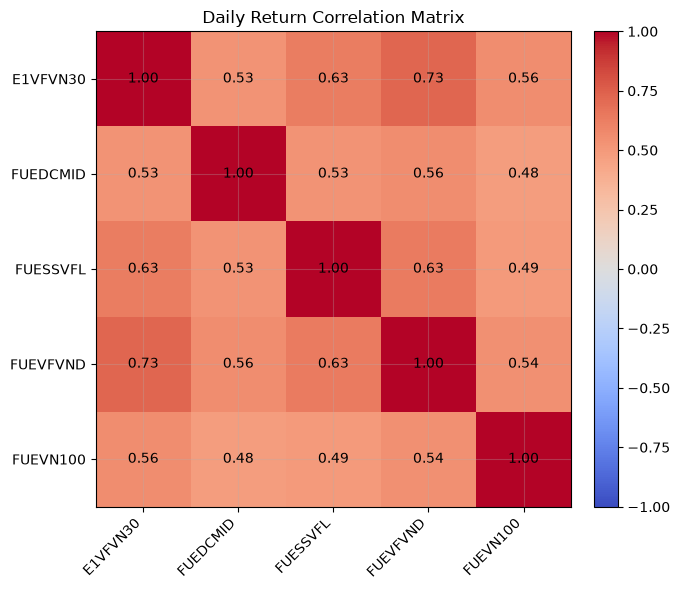

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for row_index in range(len(correlation_matrix.index)):
    for column_index in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[row_index, column_index]
        ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", color="black")

ax.set_title("Daily Return Correlation Matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 9. Normalized Price Performance

Normalize each ETF's closing price to 1.0 at its first available observation. This makes performance comparable even when ETFs have different price levels.

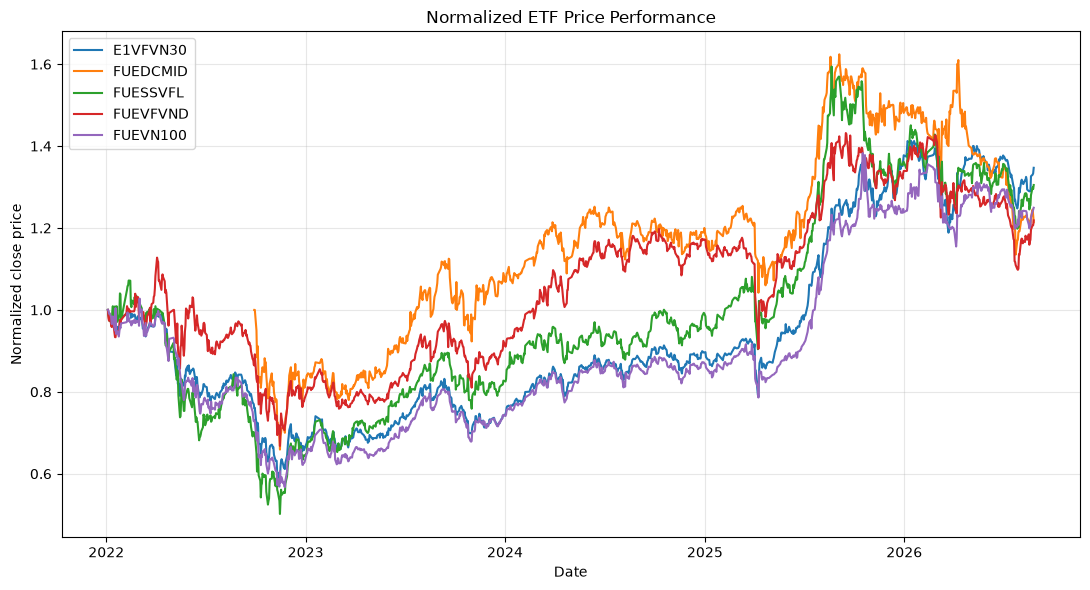

In [14]:
fig, ax = plt.subplots()
for symbol, group in analysis_df.groupby("symbol"):
    ax.plot(group["date"], group["normalized_close"], label=symbol)

ax.set_title("Normalized ETF Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized close price")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Cumulative Return

Plot cumulative return based on daily close-to-close percentage returns.

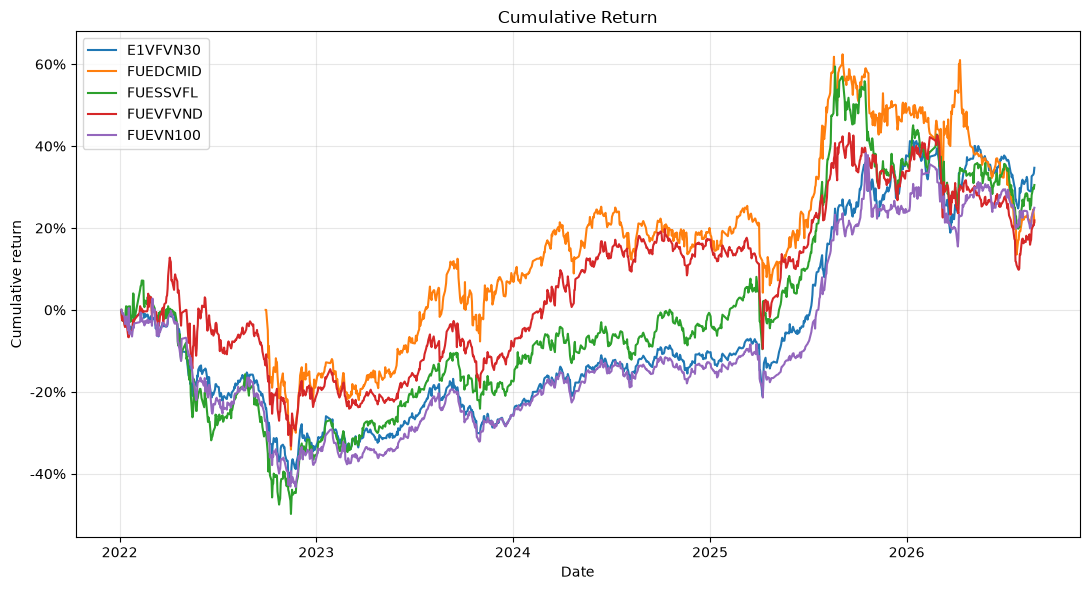

In [15]:
fig, ax = plt.subplots()
for symbol, group in analysis_df.groupby("symbol"):
    ax.plot(group["date"], group["cumulative_return"], label=symbol)

ax.set_title("Cumulative Return")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Rolling 20-Day Volatility

Plot rolling 20-day annualized volatility. This shows how short-term risk changes over time.

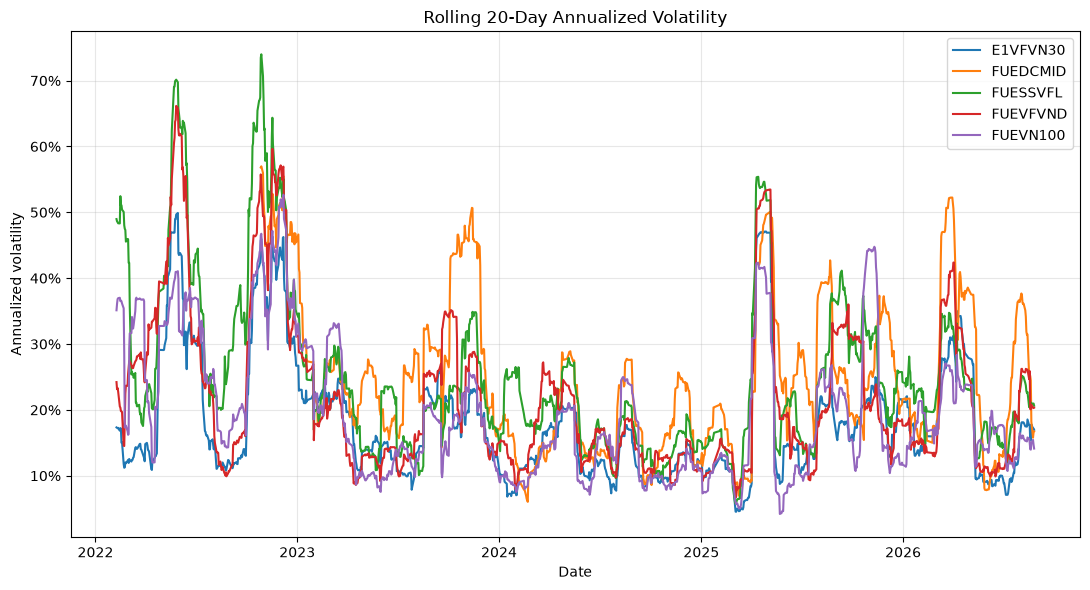

In [16]:
fig, ax = plt.subplots()
for symbol, group in analysis_df.groupby("symbol"):
    ax.plot(group["date"], group["rolling_volatility_20"], label=symbol)

ax.set_title("Rolling 20-Day Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Drawdown

Drawdown measures the decline from the previous cumulative return peak. It is useful for understanding downside risk during difficult market periods.

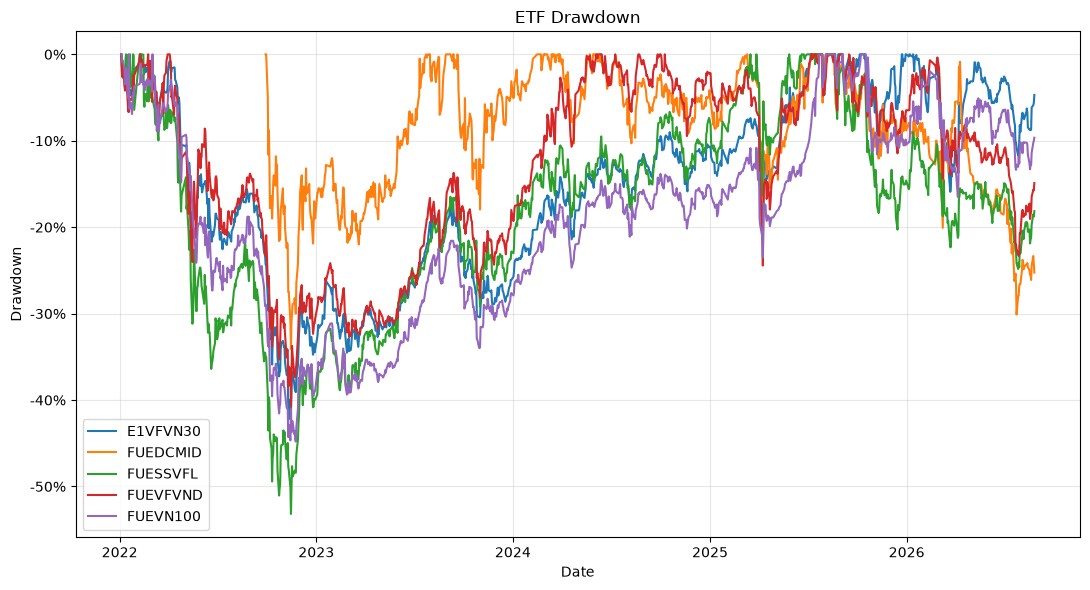

In [17]:
fig, ax = plt.subplots()
for symbol, group in analysis_df.groupby("symbol"):
    ax.plot(group["date"], group["drawdown"], label=symbol)

ax.set_title("ETF Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Notes for Graduation Report

This EDA supports the decision-support system by documenting the historical data coverage, return behavior, volatility, drawdown risk, and return correlations across the Vietnamese ETF universe. These outputs can later inform technical indicators and machine-learning feature engineering, but no predictive modeling or final recommendation logic is implemented in this notebook.